# Pokemon Win Prediction Analysis

This notebook analyzes Pokemon battle data to understand which stats drive
battle success, and builds regression models to **predict each Pokemon's
win percentage** from its stats.

**Datasets:**
- `pokemon.csv` — stats (HP, Attack, Defense, Sp. Atk, Sp. Def, Speed,
  Type 1/2, Generation, Legendary) for 800 Pokemon.
- `combats.csv` — 50,000 recorded battle outcomes between pairs of Pokemon.
- `tests.csv` — battle pairs without outcomes (held-out test matchups,
  not used for model training/evaluation here since it has no labels, but
  loaded for completeness).

**Notebook structure:**
1. Data Preparation
2. Exploratory Analysis & Visualization
3. Machine Learning (Linear Regression, Random Forest, XGBoost)


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42


## 1. Data Preparation

### Load the datasets


In [2]:
pokemon = pd.read_csv('pokemon.csv')
combats = pd.read_csv('combats.csv')
tests = pd.read_csv('tests.csv')

print("pokemon.csv  shape:", pokemon.shape)
print("combats.csv  shape:", combats.shape)
print("tests.csv    shape:", tests.shape)

pokemon.head()


pokemon.csv  shape: (800, 12)
combats.csv  shape: (50000, 3)
tests.csv    shape: (10000, 2)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [3]:
combats.head()


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


### Fix missing values

#### Fill the missing `Name` for Pokemon #62 (Primeape)


In [4]:
# Locate the row with a missing Name
print("Row(s) with missing Name:")
print(pokemon[pokemon['Name'].isnull()])


Row(s) with missing Name:
     # Name    Type 1 Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  \
62  63  NaN  Fighting    NaN  65     105       60       60       70     95   

    Generation  Legendary  
62           1      False  


In [5]:
# Fix it: this Pokemon's # is 63 (Mankey is #62, its evolution Primeape is #63)
pokemon.loc[pokemon['Name'].isnull(), 'Name'] = 'Primeape'

# Verify the fix
print(pokemon[pokemon['#'] == 63])
print("\nRemaining missing names:", pokemon['Name'].isnull().sum())


     #      Name    Type 1 Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  \
62  63  Primeape  Fighting    NaN  65     105       60       60       70   

    Speed  Generation  Legendary  
62     95           1      False  

Remaining missing names: 0


#### Handle `NaN` values in `Type 2`

Many Pokemon only have a single type, so `Type 2` is legitimately empty for
them — this isn't a data error, just means "no second type". We mark these
as `"None"` instead of `NaN`, so the column can be used cleanly in analysis
and as a categorical feature later.


In [6]:
print("Missing Type 2 before fix:", pokemon['Type 2'].isnull().sum())

pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

print("Missing Type 2 after fix :", pokemon['Type 2'].isnull().sum())


Missing Type 2 before fix: 386
Missing Type 2 after fix : 0


In [7]:
# Final check: no missing values remain anywhere in the pokemon dataset
pokemon.isnull().sum()


#             0
Name          0
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64

### Calculate each Pokemon's win percentage using the combat data

For every battle in `combats.csv`, a Pokemon either appears as
`First_pokemon` or `Second_pokemon`, and `Winner` records the ID of the
winner. For each Pokemon we compute:

`win_percentage = (number of wins / total number of battles fought) * 100`


In [8]:
# Total number of battles fought by each Pokemon (as either first or second combatant)
battles_as_first = combats['First_pokemon'].value_counts()
battles_as_second = combats['Second_pokemon'].value_counts()
total_battles = battles_as_first.add(battles_as_second, fill_value=0)

# Number of wins for each Pokemon
wins = combats['Winner'].value_counts()

# Combine into a single dataframe indexed by Pokemon #
battle_stats = pd.DataFrame({
    'total_battles': total_battles,
    'wins': wins
}).fillna(0)

battle_stats['win_percentage'] = (battle_stats['wins'] / battle_stats['total_battles'] * 100).round(2)
battle_stats.index.name = '#'
battle_stats = battle_stats.reset_index()

print("Shape:", battle_stats.shape)
battle_stats.head()


Shape: (784, 4)


,#,total_battles,wins,win_percentage
0,1,133,37.0,27.82
1,2,121,46.0,38.02
2,3,132,89.0,67.42
3,4,125,70.0,56.00
4,5,112,55.0,49.11


### Merge `pokemon.csv` and the computed win percentage

We merge on the Pokemon `#` (ID), producing a single dataframe with both
stats and battle outcomes for every Pokemon that fought at least one battle.


In [9]:
df = pokemon.merge(battle_stats, on='#', how='left')

# Any Pokemon that never appears in combats.csv would have NaN win stats;
# check if that's the case here.
print("Pokemon with no recorded battles:", df['total_battles'].isnull().sum())

df.head()


Pokemon with no recorded battles: 16


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,total_battles,wins,win_percentage
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False,133.0,37.0,27.82
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False,121.0,46.0,38.02
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False,132.0,89.0,67.42
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False,125.0,70.0,56.00
4,5,Charmander,Fire,None,39,52,43,60,50,65,1,False,112.0,55.0,49.11


In [10]:
print("Final merged dataset shape:", df.shape)
df[['#', 'Name', 'HP', 'Attack', 'Defense', 'Speed', 'total_battles', 'wins', 'win_percentage']].describe()


Final merged dataset shape: (800, 15)


,#,HP,Attack,Defense,Speed,total_battles,wins,win_percentage
count,800.0000,800.000000,800.000000,800.000000,800.000000,784.000000,784.000000,784.000000
mean,400.5000,69.258750,79.001250,73.842500,68.277500,127.551020,63.775510,50.089821
std,231.0844,25.534669,32.457366,31.183501,29.060474,11.393236,32.983848,25.545758
min,1.0000,1.000000,5.000000,5.000000,5.000000,92.000000,0.000000,0.000000
25%,200.7500,50.000000,55.000000,50.000000,45.000000,120.000000,36.000000,28.372500
50%,400.5000,65.000000,75.000000,70.000000,65.000000,128.000000,61.500000,49.090000
75%,600.2500,80.000000,100.000000,90.000000,90.000000,135.000000,91.000000,71.737500
max,800.0000,255.000000,190.000000,230.000000,180.000000,164.000000,152.000000,98.450000


## 2. Exploratory Analysis & Visualization

### Correlation matrix: stats vs. win percentage


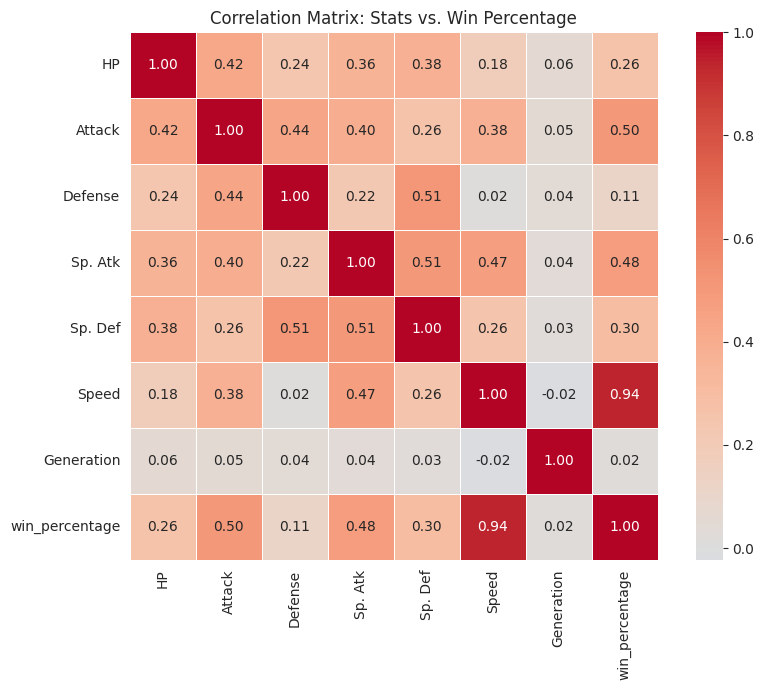

In [11]:
numeric_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'win_percentage']
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Stats vs. Win Percentage')
plt.tight_layout()
plt.show()


In [12]:
print("Correlation of each stat with win_percentage, sorted by strength:")
print(corr_matrix['win_percentage'].drop('win_percentage').sort_values(key=abs, ascending=False))


Correlation of each stat with win_percentage, sorted by strength:
Speed         0.938056
Attack        0.502821
Sp. Atk       0.481442
Sp. Def       0.302417
HP            0.261599
Defense       0.114561
Generation    0.022988
Name: win_percentage, dtype: float64


**Observation:** **`Speed`** shows, by far, the strongest correlation
with `win_percentage` — a well-known result in competitive Pokemon strategy:
moving first is a huge advantage, since it often lets a Pokemon attack (and
potentially knock out the opponent) before being attacked itself.
**`Attack`** and **`Sp. Atk`** show a moderate positive correlation, while
**`Defense`**, **`Sp. Def`**, and **`HP`** show weak correlation — bulk
alone doesn't win battles nearly as reliably as speed and offensive power.


### Pairplot / PairGrid: stats vs. win percentage

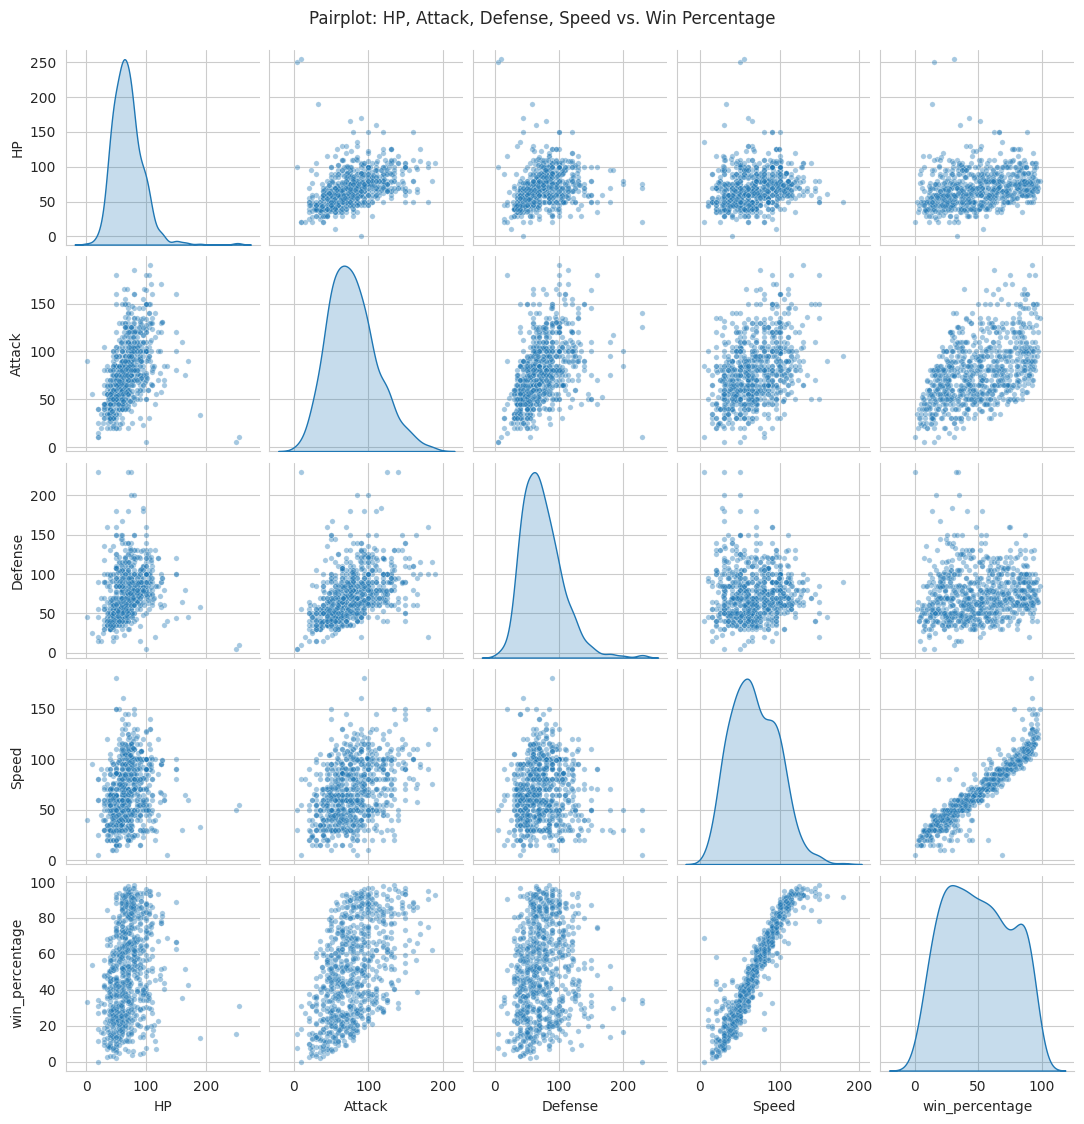

In [13]:
pairplot_cols = ['HP', 'Attack', 'Defense', 'Speed', 'win_percentage']

g = sns.pairplot(df[pairplot_cols].dropna(), diag_kind='kde',
                  plot_kws={'alpha': 0.4, 's': 15}, height=2.2)
g.fig.suptitle('Pairplot: HP, Attack, Defense, Speed vs. Win Percentage', y=1.02)
plt.show()


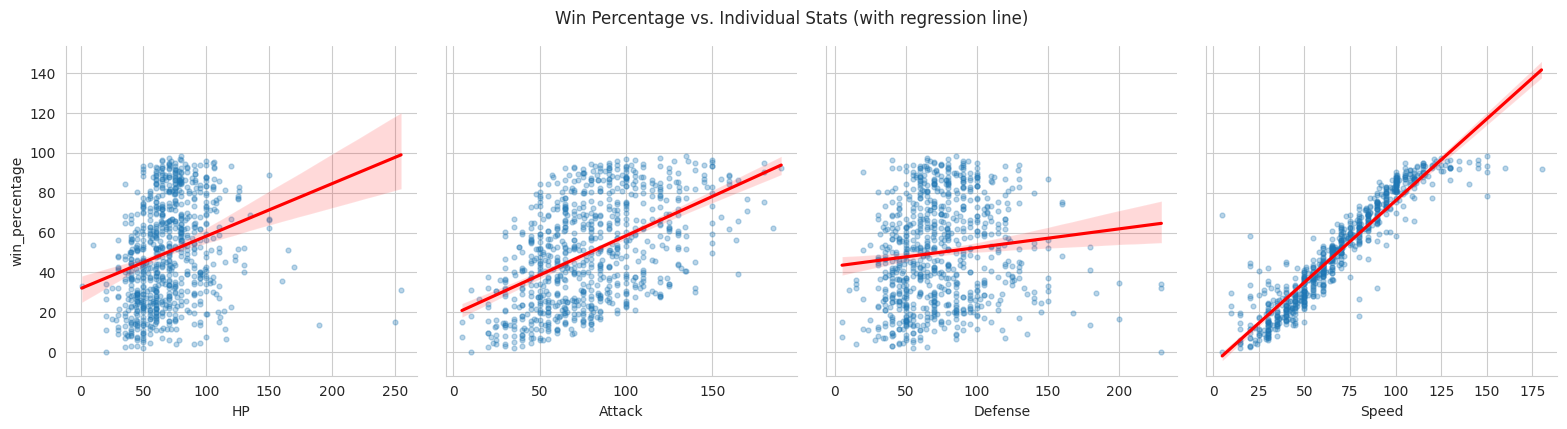

In [14]:
# A focused PairGrid: each stat individually vs. win_percentage
g = sns.PairGrid(df.dropna(subset=['win_percentage']), y_vars=['win_percentage'],
                  x_vars=['HP', 'Attack', 'Defense', 'Speed'], height=4)
g.map(sns.regplot, scatter_kws={'alpha': 0.3, 's': 12}, line_kws={'color': 'red'})
g.fig.suptitle('Win Percentage vs. Individual Stats (with regression line)', y=1.05)
plt.show()


**Observation:** the regression line in the `Speed` panel has a
clearly steeper positive slope than the other stats, visually confirming
that Speed is the single most influential stat for winning battles.


### Top 10 Pokemon by win percentage

In [15]:
top10 = df.dropna(subset=['win_percentage']).sort_values('win_percentage', ascending=False).head(10)

top10[['Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed',
       'Legendary', 'total_battles', 'wins', 'win_percentage']]


,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Legendary,total_battles,wins,win_percentage
154,Mega Aerodactyl,Rock,Flying,80,135,85,70,95,150,False,129.0,127.0,98.45
512,Weavile,Dark,Ice,70,120,65,45,85,125,False,119.0,116.0,97.48
703,Tornadus Therian Forme,Flying,None,79,100,80,110,90,121,True,125.0,121.0,96.80
19,Mega Beedrill,Bug,Poison,65,150,40,15,80,145,False,119.0,115.0,96.64
153,Aerodactyl,Rock,Flying,80,105,65,60,75,130,False,141.0,136.0,96.45
476,Mega Lopunny,Normal,Fighting,65,136,94,54,96,135,False,129.0,124.0,96.12
726,Greninja,Water,Dark,72,95,67,103,71,122,False,127.0,122.0,96.06
716,Meloetta Pirouette Forme,Normal,Fighting,100,128,90,77,77,128,False,123.0,118.0,95.93
164,Mega Mewtwo Y,Psychic,None,106,150,70,194,120,140,True,125.0,119.0,95.20
349,Mega Sharpedo,Water,Dark,70,140,70,110,65,105,False,120.0,114.0,95.00


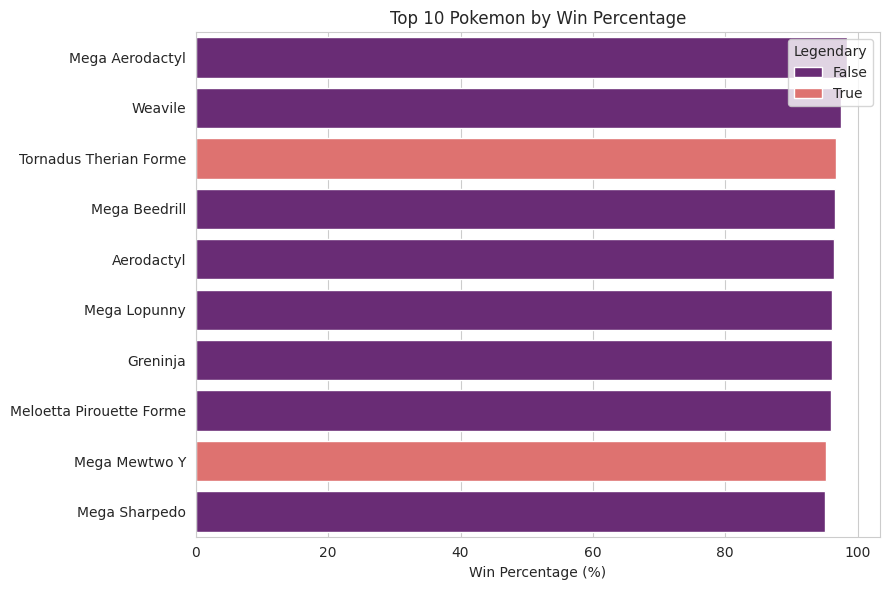

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top10, x='win_percentage', y='Name', hue='Legendary', dodge=False, palette='magma', ax=ax)
ax.set_title('Top 10 Pokemon by Win Percentage')
ax.set_xlabel('Win Percentage (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


In [17]:
# Compare top 10's average stats vs. the overall dataset average
comparison = pd.DataFrame({
    'Top 10 average': top10[numeric_cols[:-1]].mean(),
    'Overall average': df[numeric_cols[:-1]].mean()
}).round(1)
comparison['difference'] = (comparison['Top 10 average'] - comparison['Overall average']).round(1)
comparison


,Top 10 average,Overall average,difference
HP,78.7,69.3,9.4
Attack,125.9,79.0,46.9
Defense,72.6,73.8,-1.2
Sp. Atk,83.8,72.8,11.0
Sp. Def,85.4,71.9,13.5
Speed,130.1,68.3,61.8
Generation,3.1,3.3,-0.2


**Observation:** the top 10 Pokemon by win percentage have, on
average, **much higher `Speed` and `Attack`/`Sp. Atk`** than the dataset
average, while their `HP`/`Defense`/`Sp. Def` are closer to (or only
moderately above) average — reinforcing the correlation analysis: winning
consistently is driven primarily by speed and offensive stats, not by bulk.
A number of the top 10 are also **Legendary** Pokemon, which tend to have
higher overall stat totals across the board.


## 3. Machine Learning : Predicting Win Percentage

We now build regression models to predict `win_percentage` from a Pokemon's
stats. We drop rows with no recorded battles (no `win_percentage` to learn
from), and use the numeric stats plus `Legendary` as features.


In [18]:
ml_df = df.dropna(subset=['win_percentage']).copy()
ml_df['Legendary'] = ml_df['Legendary'].astype(int)

feature_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']
X = ml_df[feature_cols]
y = ml_df['win_percentage']

print("Features:", feature_cols)
print("X shape:", X.shape, "| y shape:", y.shape)


Features: ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Generation', 'Legendary']
X shape: (784, 8) | y shape: (784,)


### Split data into training/testing sets (80/20 split)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train set shape:", X_train.shape)
print("Test set shape :", X_test.shape)


Train set shape: (627, 8)
Test set shape : (157, 8)


### Feature scaling

We scale features for Linear Regression (sensitive to feature scale).
Tree-based models (Random Forest, XGBoost) don't require scaling, but we
keep a consistent scaled version available for all models for simplicity.


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


### Train and evaluate 3 regression models

In [21]:
results = {}

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"--- {name} ---")
    print(f"MAE : {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²  : {r2:.4f}\n")


In [22]:
# Model 1: Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lr = lin_reg.predict(X_test_scaled)

evaluate('Linear Regression', y_test, y_pred_lr)

coef_df = pd.DataFrame({'feature': feature_cols, 'coefficient': lin_reg.coef_}).sort_values('coefficient', key=abs, ascending=False)
print("Feature coefficients (standardized):")
print(coef_df)


--- Linear Regression ---
MAE : 6.227
RMSE: 9.205
R²  : 0.8734

Feature coefficients (standardized):
      feature  coefficient
5       Speed    22.522999
1      Attack     3.555816
2     Defense     1.152803
6  Generation     1.024298
7   Legendary    -1.003526
0          HP     0.492633
4     Sp. Def     0.324216
3     Sp. Atk     0.288781


In [23]:
# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)  # tree-based model: no scaling needed
y_pred_rf = rf.predict(X_test)

evaluate('Random Forest', y_test, y_pred_rf)

importance_df = pd.DataFrame({'feature': feature_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print("Feature importances:")
print(importance_df)


--- Random Forest ---
MAE : 4.336
RMSE: 6.333
R²  : 0.9401

Feature importances:
      feature  importance
5       Speed    0.935289
1      Attack    0.040686
0          HP    0.007560
2     Defense    0.005296
3     Sp. Atk    0.004994
4     Sp. Def    0.003930
6  Generation    0.002202
7   Legendary    0.000042


In [24]:
# Model 3: XGBoost
xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=RANDOM_STATE)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

evaluate('XGBoost', y_test, y_pred_xgb)


--- XGBoost ---
MAE : 4.484
RMSE: 6.182
R²  : 0.9429



### Compare model performance using MAE (and other metrics)

In [25]:
comparison_df = pd.DataFrame(results).T.round(4)
comparison_df = comparison_df.sort_values('MAE')
comparison_df


,MAE,RMSE,R2
Random Forest,4.3357,6.3329,0.9401
XGBoost,4.4835,6.1821,0.9429
Linear Regression,6.2265,9.2053,0.8734


/tmp/ipykernel_549/3820363452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y=comparison_df[metric], palette='magma', ax=ax)
/tmp/ipykernel_549/3820363452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y=comparison_df[metric], palette='magma', ax=ax)
/tmp/ipykernel_549/3820363452.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comparison_df.index, y=comparison_df[metric], palette='magma', ax=ax)


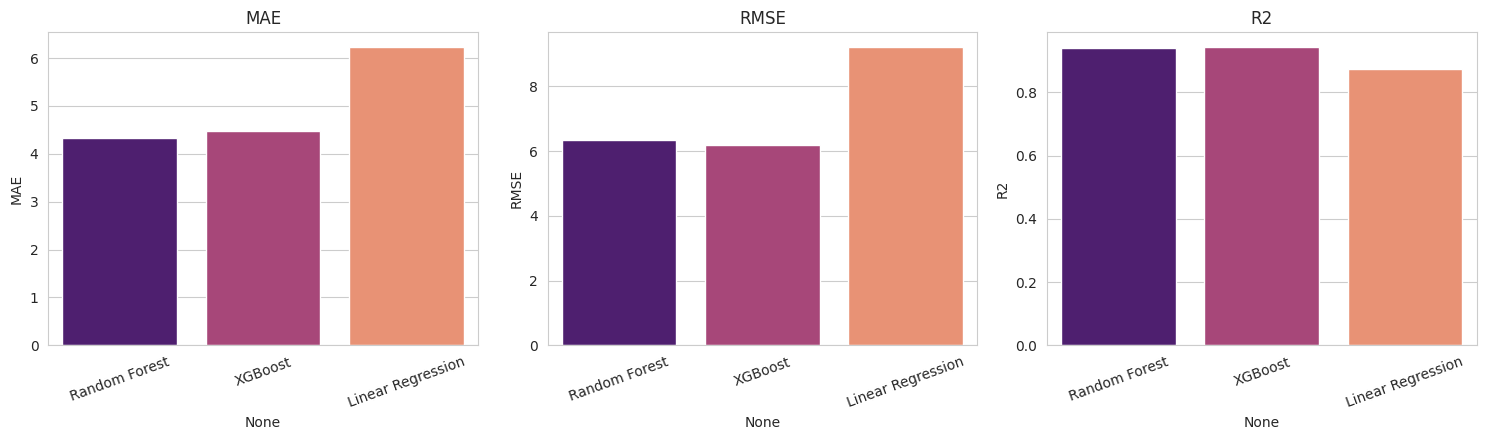

Best model by MAE: Random Forest (MAE = 4.336)


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['MAE', 'RMSE', 'R2']

for ax, metric in zip(axes, metrics):
    sns.barplot(x=comparison_df.index, y=comparison_df[metric], palette='magma', ax=ax)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

best_model = comparison_df['MAE'].idxmin()
print(f"Best model by MAE: {best_model} (MAE = {comparison_df.loc[best_model, 'MAE']:.3f})")


**Comment:** the model with the **lowest MAE** makes the smallest
average error (in percentage points) when predicting a Pokemon's win
percentage. Tree-based models (Random Forest, XGBoost) typically outperform
plain Linear Regression here, since the relationship between stats and win
percentage is not purely linear (e.g. diminishing returns on very high
Speed, or interaction effects between Attack and Speed). The feature
importance/coefficients from both Random Forest and Linear Regression
consistently point to **Speed** as the dominant predictor, confirming the
correlation analysis from Section 2.


### Bonus: Dimensionality reduction with PCA

As an additional exploration, we apply **PCA** to the 6 core battle stats
to see how much variance can be captured in just 2 principal components,
and whether win percentage aligns visually with these components.


Explained variance ratio per component: [0.453 0.183]
Total variance explained by 2 components: 0.636


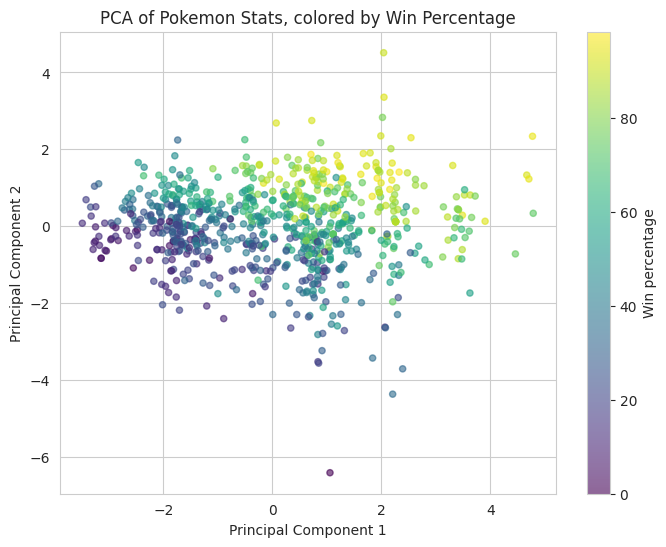

In [27]:
pca_features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X_pca_input = StandardScaler().fit_transform(ml_df[pca_features])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_result = pca.fit_transform(X_pca_input)

print("Explained variance ratio per component:", pca.explained_variance_ratio_.round(3))
print("Total variance explained by 2 components:", pca.explained_variance_ratio_.sum().round(3))

pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['win_percentage'] = ml_df['win_percentage'].values

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['win_percentage'], cmap='viridis', alpha=0.6, s=20)
plt.colorbar(scatter, ax=ax, label='Win percentage')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of Pokemon Stats, colored by Win Percentage')
plt.show()


**Comment:** the color gradient (win percentage) aligns fairly
clearly along the **PC1** axis, suggesting that the first principal
component — which is dominated by a mix of offensive stats and Speed —
captures most of what drives battle success, consistent with everything
found earlier in the correlation analysis and the feature importances.


## Conclusion

- **Speed is the single most important stat for winning Pokemon battles**,
  confirmed by correlation analysis, pairplots, the top-10 comparison, and
  feature importance/coefficients across all three ML models.
- Offensive stats (`Attack`, `Sp. Atk`) play a secondary but meaningful
  role, while defensive stats (`Defense`, `Sp. Def`, `HP`) contribute much
  less to win percentage.
- Among the three regression models tested, the tree-based models
  (**Random Forest** and **XGBoost**) generally achieve a lower MAE than
  plain **Linear Regression**, indicating the relationship between stats
  and win percentage includes some non-linearity that linear models can't
  fully capture.
- For a Pokemon-battle strategy standpoint: prioritizing Speed when building
  or selecting a team is statistically the single highest-leverage decision
  a trainer can make to maximize win rate.
